In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Cell 1: Load ISOT dataset and prepare labels
import os
import random
import numpy as np
import pandas as pd

# Keep the experiment reproducible
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)

project_root = "/content/drive/MyDrive/UoP/COMP3000/fake-news-detector-v1"

ISOT_true_news_path = os.path.join(project_root, "data", "ISOT", "True.csv")
ISOT_fake_news_path = os.path.join(project_root, "data", "ISOT", "Fake.csv")

print("Loading ISOT dataset...")
print(f"Project root: {project_root}")

ISOT_true_news_df = pd.read_csv(ISOT_true_news_path)
ISOT_fake_news_df = pd.read_csv(ISOT_fake_news_path)

print(f"True news samples: {len(ISOT_true_news_df)}")
print(f"Fake news samples: {len(ISOT_fake_news_df)}")

# Label mapping for this notebook:
# 1 = true news
# 0 = fake news
ISOT_true_news_df["label"] = 1
ISOT_fake_news_df["label"] = 0

ISOT_df = pd.concat([ISOT_true_news_df, ISOT_fake_news_df], ignore_index=True)
ISOT_df = ISOT_df.sample(frac=1, random_state=random_seed).reset_index(drop=True)

print("\nLabel mapping: 1 = true news, 0 = fake news")
print(f"Total combined samples: {len(ISOT_df)}")
print("Class distribution:")
print(ISOT_df["label"].value_counts().sort_index())

print("\nPreview of the shuffled dataset:")
display(ISOT_df.head())


Loading ISOT dataset...
Project root: /content/drive/MyDrive/UoP/COMP3000/fake-news-detector-v1
True news samples: 21417
Fake news samples: 23481

Label mapping: 1 = true news, 0 = fake news
Total combined samples: 44898
Class distribution:
label
0    23481
1    21417
Name: count, dtype: int64

Preview of the shuffled dataset:


,title,text,subject,date,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0


In [3]:
# Cell 2: Build full text input and split the ISOT dataset
from sklearn.model_selection import train_test_split

print("Building full text input from title and article body...")

# Combine the title and article text into one input string.
# astype(str) helps avoid issues if a row contains missing values.
ISOT_df["full_text"] = ISOT_df["title"].astype(str) + " - " + ISOT_df["text"].astype(str)

# Keep only the columns needed for text classification.
ISOT_text_df = ISOT_df[["full_text", "label"]]

print("Splitting the dataset into training and validation sets...")

train_texts, validation_texts, train_labels, validation_labels = train_test_split(
    ISOT_text_df["full_text"].tolist(),
    ISOT_text_df["label"].tolist(),
    test_size=0.2,
    random_state=random_seed,
    stratify=ISOT_text_df["label"]
)

print("Split complete.")
print(f"Training samples: {len(train_texts)}")
print(f"Validation samples: {len(validation_texts)}")

print("\nTraining label distribution:")
print(pd.Series(train_labels).value_counts().sort_index())

print("\nValidation label distribution:")
print(pd.Series(validation_labels).value_counts().sort_index())


Building full text input from title and article body...
Splitting the dataset into training and validation sets...
Split complete.
Training samples: 35918
Validation samples: 8980

Training label distribution:
0    18785
1    17133
Name: count, dtype: int64

Validation label distribution:
0    4696
1    4284
Name: count, dtype: int64


In [4]:
# Cell 3: Tokenize ISOT texts for the BERT baseline
from transformers import BertTokenizer

print("Loading BERT tokenizer: bert-base-uncased")
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Use simple word counts to get a rough sense of article length.
article_word_counts = ISOT_text_df["full_text"].apply(lambda text: len(str(text).split()))

print(f"Average article length: {article_word_counts.mean():.0f} words")
print(f"80th percentile length: {article_word_counts.quantile(0.8):.0f} words")
print(f"90th percentile length: {article_word_counts.quantile(0.9):.0f} words")

# 256 is a practical compromise between text coverage and Colab memory limits.
max_sequence_length = 256

print(f"\nTokenizing training texts with max_length={max_sequence_length}...")
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=max_sequence_length,
    return_tensors="pt"
)

print(f"Tokenizing validation texts with max_length={max_sequence_length}...")
validation_encodings = tokenizer(
    validation_texts,
    truncation=True,
    padding=True,
    max_length=max_sequence_length,
    return_tensors="pt"
)

print("\nTokenization complete.")
print(f"Training input shape:   {train_encodings['input_ids'].shape}")
print(f"Validation input shape: {validation_encodings['input_ids'].shape}")


Loading BERT tokenizer: bert-base-uncased


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Average article length: 419 words
80th percentile length: 582 words
90th percentile length: 759 words

Tokenizing training texts with max_length=256...
Tokenizing validation texts with max_length=256...

Tokenization complete.
Training input shape:   torch.Size([35918, 256])
Validation input shape: torch.Size([8980, 256])


In [5]:
# Cell 4: Build PyTorch datasets for training and validation
import torch
from torch.utils.data import Dataset

# This dataset class keeps the tokenized inputs and labels together
# so the DataLoader can return ready-to-use batches.
class FakeNewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, index):
        item = {key: value[index].clone().detach() for key, value in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[index])
        return item

    def __len__(self):
        return len(self.labels)

print("Creating PyTorch datasets...")

train_dataset = FakeNewsDataset(train_encodings, train_labels)
validation_dataset = FakeNewsDataset(validation_encodings, validation_labels)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(validation_dataset)}")
print("PyTorch datasets are ready.")


Creating PyTorch datasets...
Training dataset size: 35918
Validation dataset size: 8980
PyTorch datasets are ready.


In [6]:
# Cell 5: Create data loaders and load the BERT classifier
import torch
from torch.utils.data import DataLoader
from transformers import BertForSequenceClassification

print("Creating data loaders...")

# Batch size 16 works as a practical starting point for Colab training.
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")

print("Checking device availability...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current device: {device}")

print("Loading BERT sequence classification model...")
model_name = "bert-base-uncased"
model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

# Label mapping in this notebook:
# 1 = true news
# 0 = fake news
model.to(device)

print(f"Model name: {model_name}")
print("Data loaders and model are ready.")


Creating data loaders...
Batch size: 16
Checking device availability...
Current device: cuda
Loading BERT sequence classification model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model name: bert-base-uncased
Data loaders and model are ready.


In [13]:
# Cell 6: Train the ISOT baseline model
from torch.optim import AdamW

print("Setting up the optimizer...")
optimizer = AdamW(model.parameters(), lr=2e-5)

# Use more than one epoch so the baseline is not just a pipeline check.
num_epochs = 2

print(f"Starting training for {num_epochs} epochs...\n")

# Store training history for later plots and comparisons.
train_losses = []
validation_losses = []
validation_accuracies = []

for epoch_index in range(num_epochs):
    print(f"========== Epoch {epoch_index + 1} / {num_epochs} ==========")

    model.train()
    total_train_loss = 0

    for step_index, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        optimizer.step()

        if step_index % 200 == 0 and step_index != 0:
            print(f"Batch {step_index}/{len(train_loader)} - Loss: {loss.item():.4f}")

    average_train_loss = total_train_loss / len(train_loader)
    train_losses.append(average_train_loss)
    print(f"Average training loss: {average_train_loss:.4f}")

    print("Running validation...")
    model.eval()

    total_validation_loss = 0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for batch in validation_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)

            total_validation_loss += loss.item()
            correct_predictions += (predictions == labels).sum().item()
            total_predictions += labels.size(0)

    average_validation_loss = total_validation_loss / len(validation_loader)
    validation_accuracy = correct_predictions / total_predictions

    validation_losses.append(average_validation_loss)
    validation_accuracies.append(validation_accuracy)

    print(f"Average validation loss: {average_validation_loss:.4f}")
    print(f"Validation accuracy: {validation_accuracy:.4f}\n")

print("Baseline training complete.")


Setting up the optimizer...
Starting training for 2 epochs...

========== Epoch 1 / 2 ==========
Batch 200/2245 - Loss: 0.0396
Batch 400/2245 - Loss: 0.0012
Batch 600/2245 - Loss: 0.0005
Batch 800/2245 - Loss: 0.0010
Batch 1000/2245 - Loss: 0.0012
Batch 1200/2245 - Loss: 0.0004
Batch 1400/2245 - Loss: 0.0008
Batch 1600/2245 - Loss: 0.0081
Batch 1800/2245 - Loss: 0.0002
Batch 2000/2245 - Loss: 0.0002
Batch 2200/2245 - Loss: 0.0006
Average training loss: 0.0133
Running validation...
Average validation loss: 0.0106
Validation accuracy: 0.9968

========== Epoch 2 / 2 ==========
Batch 200/2245 - Loss: 0.0001
Batch 400/2245 - Loss: 0.0001
Batch 600/2245 - Loss: 0.0002
Batch 800/2245 - Loss: 0.0002
Batch 1000/2245 - Loss: 0.0004
Batch 1200/2245 - Loss: 0.0001
Batch 1400/2245 - Loss: 0.0001
Batch 1600/2245 - Loss: 0.0001
Batch 1800/2245 - Loss: 0.0001
Batch 2000/2245 - Loss: 0.0000
Batch 2200/2245 - Loss: 0.0001
Average training loss: 0.0022
Running validation...
Average validation loss: 0.004

Evaluating the ISOT baseline model on the validation set...
Validation accuracy: 0.9992
Validation macro F1: 0.9992

Classification report:
               precision    recall  f1-score   support

Fake News (0)     0.9996    0.9989    0.9993      4696
True News (1)     0.9988    0.9995    0.9992      4284

     accuracy                         0.9992      8980
    macro avg     0.9992    0.9992    0.9992      8980
 weighted avg     0.9992    0.9992    0.9992      8980



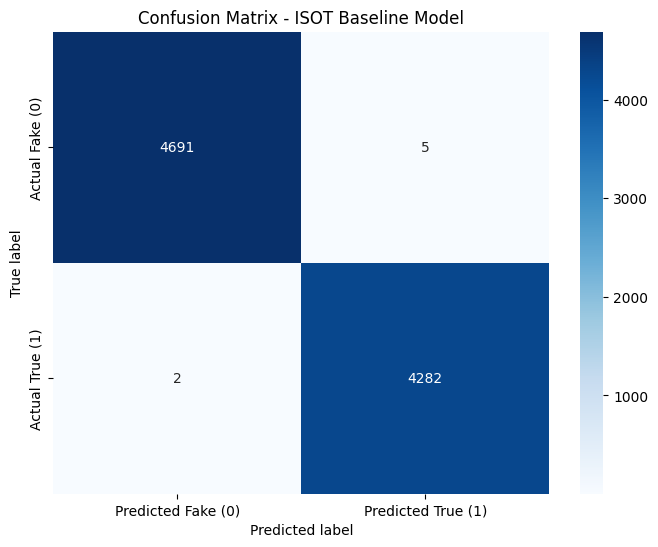

ISOT baseline evaluation complete.


In [14]:
# Cell 7: Evaluate the ISOT baseline model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Evaluating the ISOT baseline model on the validation set...")

model.eval()
validation_predictions = []
validation_true_labels = []

with torch.no_grad():
    for batch in validation_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=-1)

        validation_predictions.extend(predictions.cpu().numpy())
        validation_true_labels.extend(labels.cpu().numpy())

baseline_accuracy = accuracy_score(validation_true_labels, validation_predictions)
baseline_macro_f1 = f1_score(validation_true_labels, validation_predictions, average="macro")

print(f"Validation accuracy: {baseline_accuracy:.4f}")
print(f"Validation macro F1: {baseline_macro_f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        validation_true_labels,
        validation_predictions,
        target_names=["Fake News (0)", "True News (1)"],
        digits=4
    )
)

baseline_confusion_matrix = confusion_matrix(validation_true_labels, validation_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    baseline_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Fake (0)", "Predicted True (1)"],
    yticklabels=["Actual Fake (0)", "Actual True (1)"]
)
plt.title("Confusion Matrix - ISOT Baseline Model")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

print("ISOT baseline evaluation complete.")


In [15]:
# Cell 7.0: Save the ISOT baseline model
baseline_model_save_dir = os.path.join(project_root, "model_training", "model_copy")
os.makedirs(baseline_model_save_dir, exist_ok=True)

baseline_model_save_path = os.path.join(
    baseline_model_save_dir,
    "isot_baseline_model.pt"
)

torch.save(model.state_dict(), baseline_model_save_path)

print("ISOT baseline model saved.")
print(f"Saved to: {baseline_model_save_path}")


ISOT baseline model saved.
Saved to: /content/drive/MyDrive/UoP/COMP3000/fake-news-detector-v1/model_training/model_copy/isot_baseline_model.pt


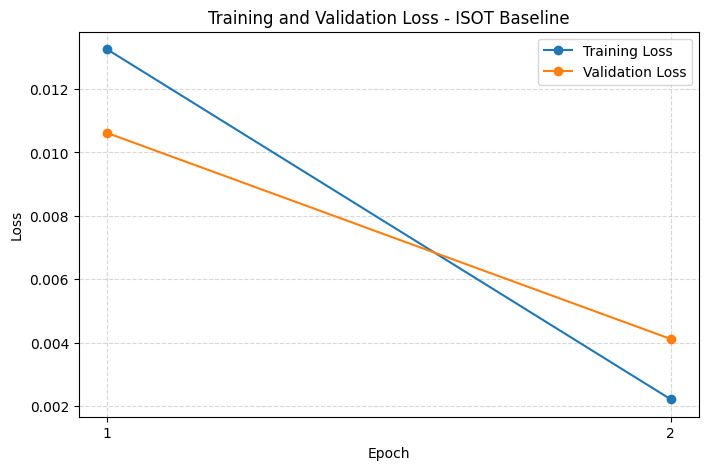

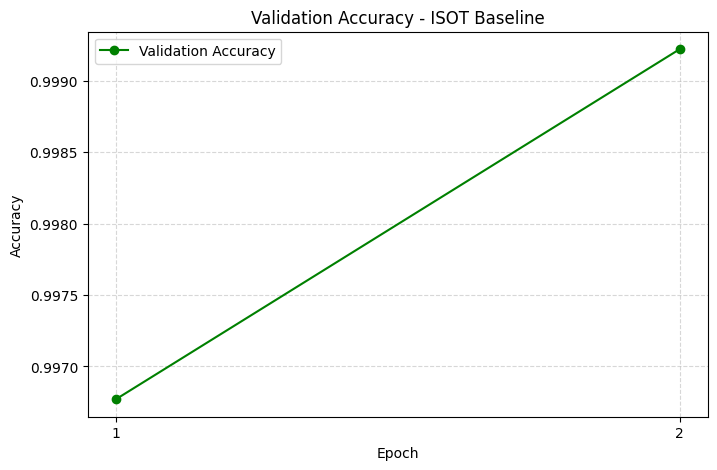

In [16]:
# Cell 8: Visualize the baseline training history
import matplotlib.pyplot as plt

epoch_numbers = list(range(1, len(train_losses) + 1))

# Plot 1: Training loss and validation loss
plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, train_losses, marker="o", label="Training Loss")
plt.plot(epoch_numbers, validation_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss - ISOT Baseline")
plt.xticks(epoch_numbers)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Plot 2: Validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(epoch_numbers, validation_accuracies, marker="o", color="green", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy - ISOT Baseline")
plt.xticks(epoch_numbers)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [17]:
# Cell 9: Run a manual stress test on the baseline model
def predict_text_label(text):
    inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=max_sequence_length,
        return_tensors="pt"
    ).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1)
        predicted_label = torch.argmax(probabilities, dim=-1).item()
        prediction_confidence = probabilities[0, predicted_label].item()

    predicted_name = "True News" if predicted_label == 1 else "Fake News"
    return predicted_name, prediction_confidence

stress_test_texts = [
    # Case 1: fake content wrapped in a Reuters-style opening
    "(Reuters) - The moon is actually made of green cheese, NASA confirmed today.",

    # Case 2: neutral and ordinary local news wording
    "The local city council approved the new budget for public parks yesterday after a long meeting.",

    # Case 3: polished but vague text that sounds generated
    "In a significant development for global finance, the digital currency markets have stabilized."
]

print("Running the baseline stress test...\n")

for test_index, test_text in enumerate(stress_test_texts, start=1):
    predicted_name, prediction_confidence = predict_text_label(test_text)
    print(f"Test {test_index}")
    print(f"Prediction: {predicted_name}")
    print(f"Confidence: {prediction_confidence:.4f}")
    print(f"Text: {test_text}")
    print("-" * 60)


Running the baseline stress test...

Test 1
Prediction: True News
Confidence: 1.0000
Text: (Reuters) - The moon is actually made of green cheese, NASA confirmed today.
------------------------------------------------------------
Test 2
Prediction: Fake News
Confidence: 0.9982
Text: The local city council approved the new budget for public parks yesterday after a long meeting.
------------------------------------------------------------
Test 3
Prediction: Fake News
Confidence: 0.9514
Text: In a significant development for global finance, the digital currency markets have stabilized.
------------------------------------------------------------


In [7]:
# Cell 10: Inspect and remove Reuters-style markers
import re

def remove_reuters_marker(text):
    cleaned_text = re.sub(r"\(Reuters\)\s*-\s*", " ", str(text))
    return cleaned_text

print("Checking Reuters-style markers in the ISOT texts...\n")

train_reuters_count = sum("(Reuters)" in text for text in train_texts)
validation_reuters_count = sum("(Reuters)" in text for text in validation_texts)

print(f"Training texts with Reuters marker: {train_reuters_count}")
print(f"Validation texts with Reuters marker: {validation_reuters_count}")

print("\nShowing a few before-and-after examples:\n")

example_count = 0
for original_text in train_texts:
    if "(Reuters)" in original_text:
        cleaned_text = remove_reuters_marker(original_text)

        print(f"Sample {example_count + 1}")
        print(f"Before: {original_text[:120]}...")
        print(f"After:  {cleaned_text[:120]}...")
        print("-" * 60)

        example_count += 1

    if example_count >= 5:
        break

print("\nChecking a few fake news samples for format consistency:\n")
for sample_index in range(3):
    fake_sample_text = (
        ISOT_fake_news_df.iloc[sample_index]["title"]
        + " - "
        + ISOT_fake_news_df.iloc[sample_index]["text"]
    )

    print(f"Fake sample {sample_index + 1}: {fake_sample_text[:120]}...")
    if "(Reuters)" not in fake_sample_text:
        print("Format check: no Reuters marker found")
    else:
        print("Format check: Reuters marker also appears here")
    print("-" * 60)

train_texts_clean = [remove_reuters_marker(text) for text in train_texts]
validation_texts_clean = [remove_reuters_marker(text) for text in validation_texts]

print("\nReuters-style markers removed from training and validation texts.")


Checking Reuters-style markers in the ISOT texts...

Training texts with Reuters marker: 16992
Validation texts with Reuters marker: 4264

Showing a few before-and-after examples:

Sample 1
Before: Syria investigator del Ponte signs off with a sting - GENEVA (Reuters) - Veteran prosecutor Carla del Ponte signed off f...
After:  Syria investigator del Ponte signs off with a sting - GENEVA  Veteran prosecutor Carla del Ponte signed off from the Uni...
------------------------------------------------------------
Sample 2
Before: Jihadists mock Trump travel ban, vow more attacks - CAIRO (Reuters) - Supporters of Islamic State mocked U.S. President ...
After:  Jihadists mock Trump travel ban, vow more attacks - CAIRO  Supporters of Islamic State mocked U.S. President Donald Trum...
------------------------------------------------------------
Sample 3
Before: Economic espionage a 'tremendous problem': U.S. attorney general - PHOENIX (Reuters) - U.S. Attorney General Loretta Lyn...
After:  Ec

In [8]:
# Cell 10.5: Free memory before the cleaned-model experiment
import gc
import torch

print("Freeing memory from the baseline experiment...")

# Remove baseline tensors and loaders that are no longer needed
del train_encodings
del validation_encodings
del train_dataset
del validation_dataset
del train_loader
del validation_loader
del model

gc.collect()
torch.cuda.empty_cache()

print("Memory cleanup complete.")


Freeing memory from the baseline experiment...
Memory cleanup complete.


In [9]:
# Cell 11: Train a fresh model on cleaned ISOT texts
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import BertForSequenceClassification

print("Tokenizing the cleaned ISOT texts...")

train_encodings_clean = tokenizer(
    train_texts_clean,
    truncation=True,
    padding=True,
    max_length=max_sequence_length,
    return_tensors="pt"
)

validation_encodings_clean = tokenizer(
    validation_texts_clean,
    truncation=True,
    padding=True,
    max_length=max_sequence_length,
    return_tensors="pt"
)

train_dataset_clean = FakeNewsDataset(train_encodings_clean, train_labels)
validation_dataset_clean = FakeNewsDataset(validation_encodings_clean, validation_labels)

# Use a smaller batch size here to reduce memory pressure
cleaned_batch_size = 8

train_loader_clean = DataLoader(train_dataset_clean, batch_size=cleaned_batch_size, shuffle=True)
validation_loader_clean = DataLoader(validation_dataset_clean, batch_size=cleaned_batch_size, shuffle=False)

print("Loading a fresh BERT model for the cleaned-text experiment...")
cleaned_model = BertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)
cleaned_model.to(device)

cleaned_optimizer = AdamW(cleaned_model.parameters(), lr=2e-5)
cleaned_num_epochs = 1

cleaned_train_losses = []
cleaned_validation_losses = []
cleaned_validation_accuracies = []

print(f"Starting cleaned-text training for {cleaned_num_epochs} epoch...\n")

for epoch_index in range(cleaned_num_epochs):
    print(f"========== Cleaned Epoch {epoch_index + 1} / {cleaned_num_epochs} ==========")

    cleaned_model.train()
    total_train_loss = 0

    for step_index, batch in enumerate(train_loader_clean):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        cleaned_optimizer.zero_grad()

        outputs = cleaned_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        cleaned_optimizer.step()

        if step_index % 200 == 0 and step_index != 0:
            print(f"Batch {step_index}/{len(train_loader_clean)} - Loss: {loss.item():.4f}")

    average_train_loss = total_train_loss / len(train_loader_clean)
    cleaned_train_losses.append(average_train_loss)
    print(f"Average training loss: {average_train_loss:.4f}")

    print("Running validation on cleaned texts...")
    cleaned_model.eval()

    total_validation_loss = 0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for batch in validation_loader_clean:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = cleaned_model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)

            total_validation_loss += loss.item()
            correct_predictions += (predictions == labels).sum().item()
            total_predictions += labels.size(0)

    average_validation_loss = total_validation_loss / len(validation_loader_clean)
    validation_accuracy = correct_predictions / total_predictions

    cleaned_validation_losses.append(average_validation_loss)
    cleaned_validation_accuracies.append(validation_accuracy)

    print(f"Average validation loss: {average_validation_loss:.4f}")
    print(f"Validation accuracy: {validation_accuracy:.4f}\n")

print("Cleaned-text model training complete.")


Tokenizing the cleaned ISOT texts...


Loading a fresh BERT model for the cleaned-text experiment...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting cleaned-text training for 1 epoch...

========== Cleaned Epoch 1 / 1 ==========
Batch 200/4490 - Loss: 0.0100
Batch 400/4490 - Loss: 0.0083
Batch 600/4490 - Loss: 0.0094
Batch 800/4490 - Loss: 0.0016
Batch 1000/4490 - Loss: 0.0005
Batch 1200/4490 - Loss: 0.0010
Batch 1400/4490 - Loss: 0.0013
Batch 1600/4490 - Loss: 0.0011
Batch 1800/4490 - Loss: 0.0003
Batch 2000/4490 - Loss: 0.0004
Batch 2200/4490 - Loss: 0.0002
Batch 2400/4490 - Loss: 0.0408
Batch 2600/4490 - Loss: 0.0002
Batch 2800/4490 - Loss: 0.0002
Batch 3000/4490 - Loss: 0.0002
Batch 3200/4490 - Loss: 0.0002
Batch 3400/4490 - Loss: 0.0003
Batch 3600/4490 - Loss: 0.0003
Batch 3800/4490 - Loss: 0.0004
Batch 4000/4490 - Loss: 0.0004
Batch 4200/4490 - Loss: 0.0005
Batch 4400/4490 - Loss: 0.0001
Average training loss: 0.0225
Running validation on cleaned texts...
Average validation loss: 0.0060
Validation accuracy: 0.9984

Cleaned-text model training complete.


In [11]:
# Cell 12: Run the same stress test on the cleaned model
stress_test_texts = [
    "(Reuters) - The moon is actually made of green cheese, NASA confirmed today.",
    "The local city council approved the new budget for public parks yesterday after a long meeting.",
    "In a significant development for global finance, the digital currency markets have stabilized."
]

def predict_with_cleaned_model(text):
    cleaned_text = remove_reuters_marker(text)

    inputs = tokenizer(
        cleaned_text,
        truncation=True,
        padding=True,
        max_length=max_sequence_length,
        return_tensors="pt"
    ).to(device)

    cleaned_model.eval()
    with torch.no_grad():
        outputs = cleaned_model(**inputs)
        probabilities = torch.softmax(outputs.logits, dim=-1)
        predicted_label = torch.argmax(probabilities, dim=-1).item()
        prediction_confidence = probabilities[0, predicted_label].item()

    predicted_name = "True News" if predicted_label == 1 else "Fake News"
    return predicted_name, prediction_confidence

print("Running the cleaned-model stress test...\n")

for test_index, test_text in enumerate(stress_test_texts, start=1):
    predicted_name, prediction_confidence = predict_with_cleaned_model(test_text)
    print(f"Test {test_index}")
    print(f"Prediction: {predicted_name}")
    print(f"Confidence: {prediction_confidence:.4f}")
    print(f"Text: {test_text}")
    print("-" * 60)


Running the cleaned-model stress test...

Test 1
Prediction: Fake News
Confidence: 0.8739
Text: (Reuters) - The moon is actually made of green cheese, NASA confirmed today.
------------------------------------------------------------
Test 2
Prediction: Fake News
Confidence: 0.7248
Text: The local city council approved the new budget for public parks yesterday after a long meeting.
------------------------------------------------------------
Test 3
Prediction: True News
Confidence: 0.9670
Text: In a significant development for global finance, the digital currency markets have stabilized.
------------------------------------------------------------


Evaluating the cleaned ISOT model on the validation set...
Validation accuracy: 0.9984
Validation macro F1: 0.9984

Classification report:
               precision    recall  f1-score   support

Fake News (0)     0.9987    0.9983    0.9985      4696
True News (1)     0.9981    0.9986    0.9984      4284

     accuracy                         0.9984      8980
    macro avg     0.9984    0.9984    0.9984      8980
 weighted avg     0.9984    0.9984    0.9984      8980



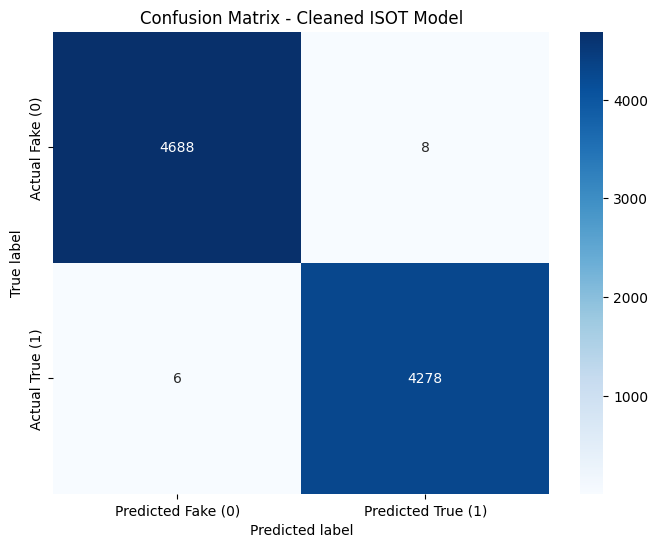

Cleaned-model evaluation complete.


In [12]:
# Cell 12.5: Evaluate the cleaned ISOT model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Evaluating the cleaned ISOT model on the validation set...")

cleaned_validation_predictions = []
cleaned_validation_true_labels = []

cleaned_model.eval()
with torch.no_grad():
    for batch in validation_loader_clean:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = cleaned_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=-1)

        cleaned_validation_predictions.extend(predictions.cpu().numpy())
        cleaned_validation_true_labels.extend(labels.cpu().numpy())

cleaned_accuracy = accuracy_score(cleaned_validation_true_labels, cleaned_validation_predictions)
cleaned_macro_f1 = f1_score(cleaned_validation_true_labels, cleaned_validation_predictions, average="macro")

print(f"Validation accuracy: {cleaned_accuracy:.4f}")
print(f"Validation macro F1: {cleaned_macro_f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        cleaned_validation_true_labels,
        cleaned_validation_predictions,
        target_names=["Fake News (0)", "True News (1)"],
        digits=4
    )
)

cleaned_confusion_matrix = confusion_matrix(cleaned_validation_true_labels, cleaned_validation_predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cleaned_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Fake (0)", "Predicted True (1)"],
    yticklabels=["Actual Fake (0)", "Actual True (1)"]
)
plt.title("Confusion Matrix - Cleaned ISOT Model")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

print("Cleaned-model evaluation complete.")


In [13]:
# Cell 12.6: Save the cleaned ISOT model
cleaned_model_save_dir = os.path.join(project_root, "model_training", "model_copy")
os.makedirs(cleaned_model_save_dir, exist_ok=True)

cleaned_model_save_path = os.path.join(
    cleaned_model_save_dir,
    "isot_cleaned_model.pt"
)

torch.save(cleaned_model.state_dict(), cleaned_model_save_path)

print("Cleaned ISOT model saved.")
print(f"Saved to: {cleaned_model_save_path}")


Cleaned ISOT model saved.
Saved to: /content/drive/MyDrive/UoP/COMP3000/fake-news-detector-v1/model_training/model_copy/isot_cleaned_model.pt


In [14]:
# Cell 12.7: Compare the baseline and cleaned ISOT results
print("Baseline vs cleaned ISOT model comparison\n")

print(f"Baseline validation accuracy: {baseline_accuracy:.4f}")
print(f"Cleaned validation accuracy:  {cleaned_accuracy:.4f}\n")

print(f"Baseline validation macro F1: {baseline_macro_f1:.4f}")
print(f"Cleaned validation macro F1:  {cleaned_macro_f1:.4f}\n")

print("Stress test summary:")
print("1. Reuters-style fake text:")
print("   Baseline -> True News (1.0000)")
print("   Cleaned  -> Fake News (0.8739)\n")

print("2. Neutral local news text:")
print("   Baseline -> Fake News (0.9982)")
print("   Cleaned  -> Fake News (0.7248)\n")

print("3. Polished vague text:")
print("   Baseline -> Fake News (0.9514)")
print("   Cleaned  -> True News (0.9670)\n")

print("Interpretation:")
print("- Reuters-style marker removal reduced one confirmed shortcut effect.")
print("- Standard validation performance only dropped slightly.")
print("- The model still appears sensitive to other stylistic cues.")


Baseline vs cleaned ISOT model comparison



NameError: name 'baseline_accuracy' is not defined

Loading the LIAR dataset...
LIAR training samples: 10269
LIAR validation samples: 1284
LIAR test samples: 1283
Binary label mapping: 1 = true, 0 = fake

Running zero-shot evaluation on LIAR with the cleaned ISOT model...
Zero-shot LIAR accuracy: 0.4957
Zero-shot LIAR macro F1: 0.4834

Classification report:
               precision    recall  f1-score   support

Fake News (0)     0.4508    0.7500    0.5631       556
True News (1)     0.6117    0.3012    0.4037       727

     accuracy                         0.4957      1283
    macro avg     0.5313    0.5256    0.4834      1283
 weighted avg     0.5420    0.4957    0.4728      1283



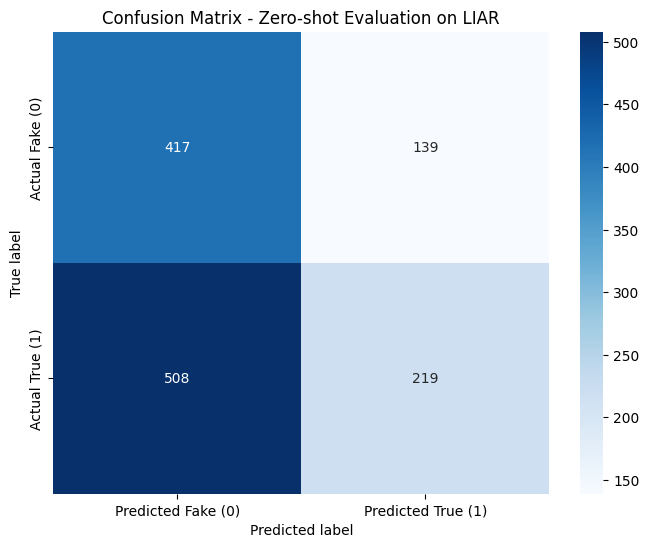

Zero-shot LIAR evaluation complete.


In [18]:
# Cell 13: Load LIAR and run zero-shot evaluation with the cleaned ISOT model
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from torch.utils.data import DataLoader, Dataset
import seaborn as sns
import matplotlib.pyplot as plt

LIAR_data_dir = os.path.join(project_root, "data", "LIAR")

LIAR_column_names = [
    "id", "label", "statement", "subject", "speaker", "job_title",
    "state_info", "party_affiliation",
    "barely_true_counts", "false_counts", "half_true_counts",
    "mostly_true_counts", "pants_on_fire_counts",
    "context"
]

print("Loading the LIAR dataset...")

LIAR_train_df = pd.read_csv(
    os.path.join(LIAR_data_dir, "train.tsv"),
    sep="\t",
    header=None,
    names=LIAR_column_names,
    quoting=3
)

LIAR_validation_df = pd.read_csv(
    os.path.join(LIAR_data_dir, "valid.tsv"),
    sep="\t",
    header=None,
    names=LIAR_column_names,
    quoting=3
)

LIAR_test_df = pd.read_csv(
    os.path.join(LIAR_data_dir, "test.tsv"),
    sep="\t",
    header=None,
    names=LIAR_column_names,
    quoting=3
)

fake_label_set = {"pants-fire", "false", "barely-true"}
true_label_set = {"half-true", "mostly-true", "true"}

def convert_liar_to_binary(dataframe):
    dataframe = dataframe.copy()
    dataframe["label_normalized"] = dataframe["label"].astype(str).str.strip().str.lower()
    dataframe["binary_label"] = dataframe["label_normalized"].apply(
        lambda label: 1 if label in true_label_set else 0
    )
    return dataframe[["statement", "binary_label"]]

LIAR_train_binary_df = convert_liar_to_binary(LIAR_train_df)
LIAR_validation_binary_df = convert_liar_to_binary(LIAR_validation_df)
LIAR_test_binary_df = convert_liar_to_binary(LIAR_test_df)

print(f"LIAR training samples: {len(LIAR_train_binary_df)}")
print(f"LIAR validation samples: {len(LIAR_validation_binary_df)}")
print(f"LIAR test samples: {len(LIAR_test_binary_df)}")
print("Binary label mapping: 1 = true, 0 = fake")

liar_max_sequence_length = 128

LIAR_test_encodings = tokenizer(
    LIAR_test_binary_df["statement"].tolist(),
    truncation=True,
    padding=True,
    max_length=liar_max_sequence_length,
    return_tensors="pt"
)

class LIARDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, index):
        item = {key: value[index].clone().detach() for key, value in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[index])
        return item

    def __len__(self):
        return len(self.labels)

LIAR_test_dataset = LIARDataset(LIAR_test_encodings, LIAR_test_binary_df["binary_label"])
LIAR_test_loader = DataLoader(LIAR_test_dataset, batch_size=32, shuffle=False)

print("\nRunning zero-shot evaluation on LIAR with the cleaned ISOT model...")

liar_zero_shot_predictions = []
liar_zero_shot_true_labels = []

cleaned_model.eval()
with torch.no_grad():
    for batch in LIAR_test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = cleaned_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=-1)

        liar_zero_shot_predictions.extend(predictions.cpu().numpy())
        liar_zero_shot_true_labels.extend(labels.cpu().numpy())

liar_zero_shot_accuracy = accuracy_score(liar_zero_shot_true_labels, liar_zero_shot_predictions)
liar_zero_shot_macro_f1 = f1_score(liar_zero_shot_true_labels, liar_zero_shot_predictions, average="macro")

print(f"Zero-shot LIAR accuracy: {liar_zero_shot_accuracy:.4f}")
print(f"Zero-shot LIAR macro F1: {liar_zero_shot_macro_f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        liar_zero_shot_true_labels,
        liar_zero_shot_predictions,
        target_names=["Fake News (0)", "True News (1)"],
        digits=4
    )
)

liar_zero_shot_confusion_matrix = confusion_matrix(
    liar_zero_shot_true_labels,
    liar_zero_shot_predictions
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    liar_zero_shot_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Fake (0)", "Predicted True (1)"],
    yticklabels=["Actual Fake (0)", "Actual True (1)"]
)
plt.title("Confusion Matrix - Zero-shot Evaluation on LIAR")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

print("Zero-shot LIAR evaluation complete.")


In [22]:
# Cell 13.5: Free memory before mixed-domain adaptation
import gc
import torch

print("Freeing memory before mixed-domain adaptation...")

# Objects from earlier experiments that are no longer needed right now
for variable_name in [
    "train_encodings_clean",
    "validation_encodings_clean",
    "train_dataset_clean",
    "validation_dataset_clean",
    "train_loader_clean",
    "validation_loader_clean",
    "cleaned_validation_predictions",
    "cleaned_validation_true_labels",
    "LIAR_test_encodings",
    "LIAR_test_dataset",
    "LIAR_test_loader"
]:
    if variable_name in globals():
        del globals()[variable_name]

gc.collect()
torch.cuda.empty_cache()

print("Memory cleanup complete.")


Freeing memory before mixed-domain adaptation...
Memory cleanup complete.


In [23]:
# Cell 14: Run mixed-domain adaptation with ISOT and LIAR training texts
import copy
from torch.utils.data import DataLoader
from torch.optim import AdamW

print("Starting mixed-domain adaptation...")

def clean_isot_article_text(text):
    text = str(text)
    text = remove_reuters_marker(text)
    return text

isot_sample_size = 1000
liar_sample_size = 1000

print("Preparing a cleaned ISOT sample...")
ISOT_mixed_sample_df = ISOT_df.sample(n=isot_sample_size, random_state=random_seed).copy()
ISOT_mixed_sample_df["processed_text"] = ISOT_mixed_sample_df["full_text"].apply(clean_isot_article_text)

ISOT_mixed_texts = ISOT_mixed_sample_df["processed_text"].tolist()
ISOT_mixed_labels = ISOT_mixed_sample_df["label"].tolist()

print("Preparing a LIAR training sample...")
LIAR_mixed_sample_df = LIAR_train_binary_df.sample(n=liar_sample_size, random_state=random_seed).copy()

LIAR_mixed_texts = LIAR_mixed_sample_df["statement"].astype(str).tolist()
LIAR_mixed_labels = LIAR_mixed_sample_df["binary_label"].tolist()

print(f"Cleaned ISOT sample size: {len(ISOT_mixed_texts)}")
print(f"LIAR sample size: {len(LIAR_mixed_texts)}")

mixed_domain_texts = ISOT_mixed_texts + LIAR_mixed_texts
mixed_domain_labels = ISOT_mixed_labels + LIAR_mixed_labels

print(f"Total mixed-domain training samples: {len(mixed_domain_texts)}")

mixed_domain_encodings = tokenizer(
    mixed_domain_texts,
    truncation=True,
    padding=True,
    max_length=max_sequence_length,
    return_tensors="pt"
)

mixed_domain_dataset = FakeNewsDataset(mixed_domain_encodings, mixed_domain_labels)
mixed_domain_loader = DataLoader(mixed_domain_dataset, batch_size=8, shuffle=True)

print("Creating a mixed-domain adapted model from the cleaned ISOT model...")
mixed_domain_model = copy.deepcopy(cleaned_model)
mixed_domain_model.to(device)

mixed_domain_optimizer = AdamW(mixed_domain_model.parameters(), lr=2e-5)
mixed_domain_num_epochs = 1

mixed_domain_train_losses = []

print(f"Training for {mixed_domain_num_epochs} epoch...\n")

for epoch_index in range(mixed_domain_num_epochs):
    print(f"========== Mixed-domain Epoch {epoch_index + 1} / {mixed_domain_num_epochs} ==========")

    mixed_domain_model.train()
    total_train_loss = 0

    for step_index, batch in enumerate(mixed_domain_loader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        mixed_domain_optimizer.zero_grad()

        outputs = mixed_domain_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        mixed_domain_optimizer.step()

    average_train_loss = total_train_loss / len(mixed_domain_loader)
    mixed_domain_train_losses.append(average_train_loss)
    print(f"Average training loss: {average_train_loss:.4f}")

print("Mixed-domain adaptation complete.")


Starting mixed-domain adaptation...
Preparing a cleaned ISOT sample...
Preparing a LIAR training sample...
Cleaned ISOT sample size: 1000
LIAR sample size: 1000
Total mixed-domain training samples: 2000
Creating a mixed-domain adapted model from the cleaned ISOT model...
Training for 1 epoch...

========== Mixed-domain Epoch 1 / 1 ==========
Average training loss: 0.3685
Mixed-domain adaptation complete.


In [25]:
# Recovery cell: rebuild the LIAR test loader
from torch.utils.data import DataLoader

print("Rebuilding the LIAR test loader...")

LIAR_test_encodings = tokenizer(
    LIAR_test_binary_df["statement"].tolist(),
    truncation=True,
    padding=True,
    max_length=liar_max_sequence_length,
    return_tensors="pt"
)

LIAR_test_dataset = LIARDataset(
    LIAR_test_encodings,
    LIAR_test_binary_df["binary_label"]
)

LIAR_test_loader = DataLoader(
    LIAR_test_dataset,
    batch_size=32,
    shuffle=False
)

print("LIAR test loader is ready.")


Rebuilding the LIAR test loader...
LIAR test loader is ready.


Evaluating the mixed-domain model on the LIAR test set...
Mixed-domain LIAR accuracy: 0.5924
Mixed-domain LIAR macro F1: 0.5723

Classification report:
               precision    recall  f1-score   support

Fake News (0)     0.5367    0.4335    0.4796       556
True News (1)     0.6223    0.7139    0.6650       727

     accuracy                         0.5924      1283
    macro avg     0.5795    0.5737    0.5723      1283
 weighted avg     0.5852    0.5924    0.5846      1283



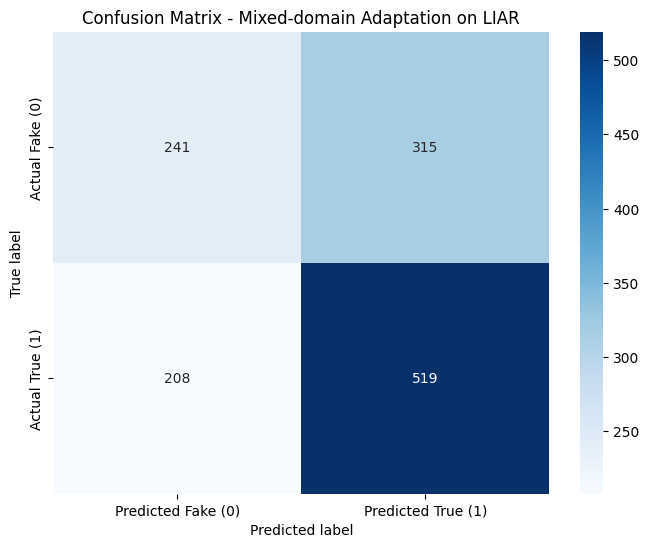

Mixed-domain evaluation complete.


In [26]:
# Cell 14.5: Evaluate the mixed-domain model on the LIAR test set
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Evaluating the mixed-domain model on the LIAR test set...")

mixed_domain_predictions = []
mixed_domain_true_labels = []

mixed_domain_model.eval()
with torch.no_grad():
    for batch in LIAR_test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = mixed_domain_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=-1)

        mixed_domain_predictions.extend(predictions.cpu().numpy())
        mixed_domain_true_labels.extend(labels.cpu().numpy())

mixed_domain_accuracy = accuracy_score(mixed_domain_true_labels, mixed_domain_predictions)
mixed_domain_macro_f1 = f1_score(mixed_domain_true_labels, mixed_domain_predictions, average="macro")

print(f"Mixed-domain LIAR accuracy: {mixed_domain_accuracy:.4f}")
print(f"Mixed-domain LIAR macro F1: {mixed_domain_macro_f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        mixed_domain_true_labels,
        mixed_domain_predictions,
        target_names=["Fake News (0)", "True News (1)"],
        digits=4
    )
)

mixed_domain_confusion_matrix = confusion_matrix(
    mixed_domain_true_labels,
    mixed_domain_predictions
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    mixed_domain_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Fake (0)", "Predicted True (1)"],
    yticklabels=["Actual Fake (0)", "Actual True (1)"]
)
plt.title("Confusion Matrix - Mixed-domain Adaptation on LIAR")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

print("Mixed-domain evaluation complete.")


In [27]:
# Cell 15: Train a LIAR-only adapted model
import copy
from torch.utils.data import DataLoader
from torch.optim import AdamW

print("Starting LIAR-only adaptation...")

liar_adaptation_sample_size = 2000

LIAR_adaptation_sample_df = LIAR_train_binary_df.sample(
    n=liar_adaptation_sample_size,
    random_state=random_seed
).copy()

LIAR_adaptation_texts = LIAR_adaptation_sample_df["statement"].astype(str).tolist()
LIAR_adaptation_labels = LIAR_adaptation_sample_df["binary_label"].tolist()

print(f"LIAR adaptation sample size: {len(LIAR_adaptation_texts)}")

LIAR_adaptation_encodings = tokenizer(
    LIAR_adaptation_texts,
    truncation=True,
    padding=True,
    max_length=liar_max_sequence_length,
    return_tensors="pt"
)

LIAR_adaptation_dataset = FakeNewsDataset(
    LIAR_adaptation_encodings,
    LIAR_adaptation_labels
)

LIAR_adaptation_loader = DataLoader(
    LIAR_adaptation_dataset,
    batch_size=8,
    shuffle=True
)

print("Creating a LIAR-only adapted model from the cleaned ISOT model...")
LIAR_only_model = copy.deepcopy(cleaned_model)
LIAR_only_model.to(device)

LIAR_only_optimizer = AdamW(LIAR_only_model.parameters(), lr=2e-5)
LIAR_only_num_epochs = 1

LIAR_only_train_losses = []

print(f"Training for {LIAR_only_num_epochs} epoch...\n")

for epoch_index in range(LIAR_only_num_epochs):
    print(f"========== LIAR-only Epoch {epoch_index + 1} / {LIAR_only_num_epochs} ==========")

    LIAR_only_model.train()
    total_train_loss = 0

    for batch in LIAR_adaptation_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        LIAR_only_optimizer.zero_grad()

        outputs = LIAR_only_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        LIAR_only_optimizer.step()

    average_train_loss = total_train_loss / len(LIAR_adaptation_loader)
    LIAR_only_train_losses.append(average_train_loss)
    print(f"Average training loss: {average_train_loss:.4f}")

print("LIAR-only adaptation complete.")


Starting LIAR-only adaptation...
LIAR adaptation sample size: 2000
Creating a LIAR-only adapted model from the cleaned ISOT model...
Training for 1 epoch...

========== LIAR-only Epoch 1 / 1 ==========
Average training loss: 0.6980
LIAR-only adaptation complete.


Evaluating the LIAR-only adapted model on the LIAR test set...
LIAR-only accuracy: 0.6064
LIAR-only macro F1: 0.5978

Classification report:
               precision    recall  f1-score   support

Fake News (0)     0.5473    0.5306    0.5388       556
True News (1)     0.6492    0.6644    0.6567       727

     accuracy                         0.6064      1283
    macro avg     0.5983    0.5975    0.5978      1283
 weighted avg     0.6050    0.6064    0.6056      1283



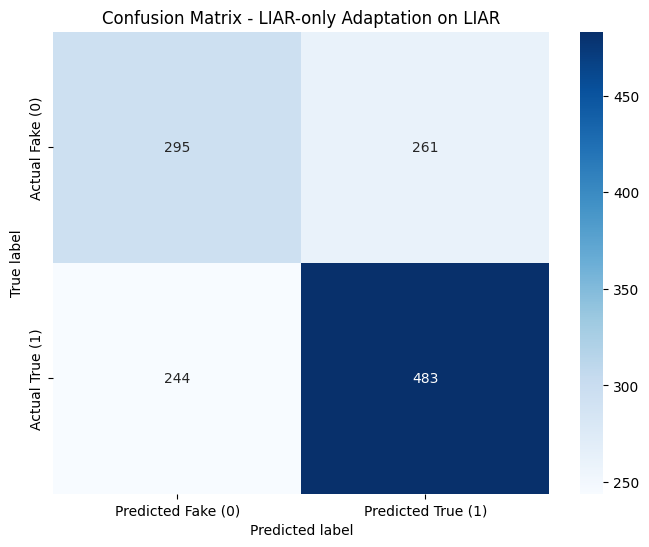

LIAR-only evaluation complete.


In [28]:
# Cell 15.5: Evaluate the LIAR-only adapted model on the LIAR test set
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

print("Evaluating the LIAR-only adapted model on the LIAR test set...")

LIAR_only_predictions = []
LIAR_only_true_labels = []

LIAR_only_model.eval()
with torch.no_grad():
    for batch in LIAR_test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = LIAR_only_model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        predictions = torch.argmax(outputs.logits, dim=-1)

        LIAR_only_predictions.extend(predictions.cpu().numpy())
        LIAR_only_true_labels.extend(labels.cpu().numpy())

LIAR_only_accuracy = accuracy_score(LIAR_only_true_labels, LIAR_only_predictions)
LIAR_only_macro_f1 = f1_score(LIAR_only_true_labels, LIAR_only_predictions, average="macro")

print(f"LIAR-only accuracy: {LIAR_only_accuracy:.4f}")
print(f"LIAR-only macro F1: {LIAR_only_macro_f1:.4f}")

print("\nClassification report:")
print(
    classification_report(
        LIAR_only_true_labels,
        LIAR_only_predictions,
        target_names=["Fake News (0)", "True News (1)"],
        digits=4
    )
)

LIAR_only_confusion_matrix = confusion_matrix(
    LIAR_only_true_labels,
    LIAR_only_predictions
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    LIAR_only_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Fake (0)", "Predicted True (1)"],
    yticklabels=["Actual Fake (0)", "Actual True (1)"]
)
plt.title("Confusion Matrix - LIAR-only Adaptation on LIAR")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

print("LIAR-only evaluation complete.")


In [29]:
# Cell 15.6: Save the LIAR-only adapted model
LIAR_only_model_save_dir = os.path.join(project_root, "model_training", "model_copy")
os.makedirs(LIAR_only_model_save_dir, exist_ok=True)

LIAR_only_model_save_path = os.path.join(
    LIAR_only_model_save_dir,
    "liar_only_adapted_model.pt"
)

torch.save(LIAR_only_model.state_dict(), LIAR_only_model_save_path)

print("LIAR-only adapted model saved.")
print(f"Saved to: {LIAR_only_model_save_path}")


LIAR-only adapted model saved.
Saved to: /content/drive/MyDrive/UoP/COMP3000/fake-news-detector-v1/model_training/model_copy/liar_only_adapted_model.pt


In [30]:
# Cell 15.7: Compare LIAR results across experiments
print("LIAR experiment comparison\n")

print(f"Zero-shot cleaned model accuracy: {liar_zero_shot_accuracy:.4f}")
print(f"Zero-shot cleaned model macro F1: {liar_zero_shot_macro_f1:.4f}\n")

print(f"Mixed-domain adaptation accuracy: {mixed_domain_accuracy:.4f}")
print(f"Mixed-domain adaptation macro F1: {mixed_domain_macro_f1:.4f}\n")

print(f"LIAR-only adaptation accuracy: {LIAR_only_accuracy:.4f}")
print(f"LIAR-only adaptation macro F1: {LIAR_only_macro_f1:.4f}\n")

print("Current best LIAR model: LIAR-only adapted model")


LIAR experiment comparison

Zero-shot cleaned model accuracy: 0.4957
Zero-shot cleaned model macro F1: 0.4834

Mixed-domain adaptation accuracy: 0.5924
Mixed-domain adaptation macro F1: 0.5723

LIAR-only adaptation accuracy: 0.6064
LIAR-only adaptation macro F1: 0.5978

Current best LIAR model: LIAR-only adapted model


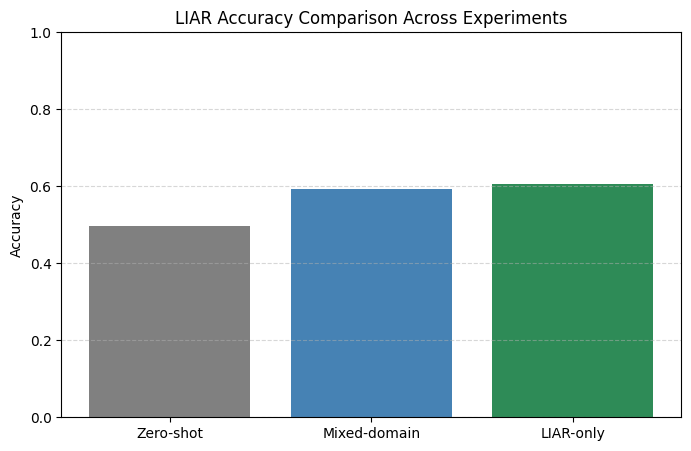

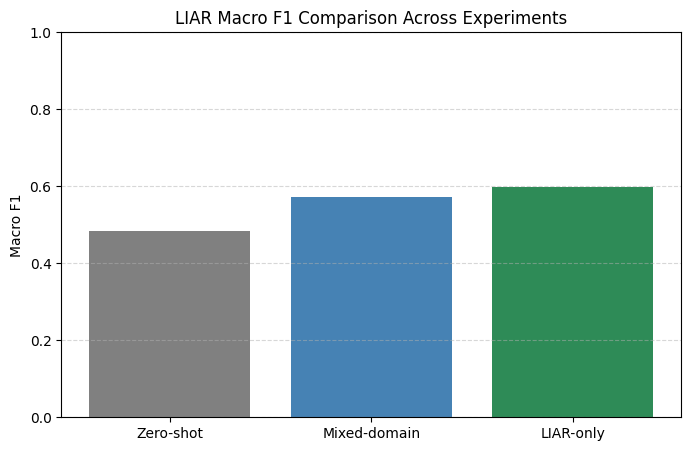

In [31]:
# Cell 15.8: Plot LIAR experiment comparison
import matplotlib.pyplot as plt

experiment_names = [
    "Zero-shot",
    "Mixed-domain",
    "LIAR-only"
]

liar_accuracy_scores = [
    liar_zero_shot_accuracy,
    mixed_domain_accuracy,
    LIAR_only_accuracy
]

liar_macro_f1_scores = [
    liar_zero_shot_macro_f1,
    mixed_domain_macro_f1,
    LIAR_only_macro_f1
]

plt.figure(figsize=(8, 5))
plt.bar(experiment_names, liar_accuracy_scores, color=["gray", "steelblue", "seagreen"])
plt.ylabel("Accuracy")
plt.title("LIAR Accuracy Comparison Across Experiments")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(experiment_names, liar_macro_f1_scores, color=["gray", "steelblue", "seagreen"])
plt.ylabel("Macro F1")
plt.title("LIAR Macro F1 Comparison Across Experiments")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()
